# Train — sheep policy (behavioural cloning, no memory)

Clone the **sheep** RuleBrain into a small memoryless network:

```
grids (C,K,K) ─CNN─┐
                   ├─▶ trunk (MLP) ─▶ heading mean (2)  ─ MSE  ─▶ teacher heading
scalars (10) ─MLP──┘                 gate logits  (3)  ─ BCE  ─▶ eat / drink / repro
                                     speed logit  (1)  ─ BCE  ─▶ speed throttle
```

Same CNN front-end as the deployed brain (`sim/neural_brain.py`), but the LSTM is replaced
by a feed-forward trunk and the critic is dropped — this is supervised imitation, not RL.
We **hold out one whole world** for validation, so the reported metrics measure
generalization to a map the network never trained on.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
for _c in (_cwd, *_cwd.parents):              # imitation.py lives in imitation_learning/
    if (_c / "notebooks" / "imitation_learning" / "imitation.py").exists():
        sys.path.insert(0, str(_c / "notebooks" / "imitation_learning")); break
    if (_c / "imitation.py").exists():
        sys.path.insert(0, str(_c)); break
import numpy as np
import matplotlib.pyplot as plt
import torch
import imitation as IL
from config import SHEEP, FOX, SPECIES_NAMES

SID = SHEEP
device = "cuda" if torch.cuda.is_available() else "cpu"
print("species:", SPECIES_NAMES[SID], "| device:", device,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

species: sheep | device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## Load the dataset

Grids stay **float16** in CPU RAM; each minibatch is sliced and moved to the GPU as float32,
so the whole dataset never has to fit in VRAM at once.

In [2]:
d = IL.load_dataset(SID)
print("rows:", d['grids'].shape[0], "| grids:", d['grids'].shape[1:],
      "| worlds:", np.bincount(d['world']))
VAL_WORLD = int(d['world'].max())        # held-out validation world (last collected)

rows: 300000 | grids: (6, 57, 57) | worlds: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000]


## Train

GPU-batched behavioural cloning. Watch `val cos` (heading cosine vs the teacher, →1 is
perfect) and the per-gate accuracies climb on the held-out world.

In [6]:
model, history = IL.train_policy(SID, d, device=device, epochs=40,
                               batch_size=512, lr=1e-3, val_world=VAL_WORLD)

  gate +rates [0.58 0.17 0.41] speed +rate 0.44 -> pos_weight gates [0.7 4.8 1.5] speed 1.3
  [sheep  1/40] loss=1.8771 (head=0.9170 gate=0.6724 speed=0.5755) | val cos=0.277 eat=0.66 drink=0.87 repro=0.85 speed=0.87
  [sheep  2/40] loss=1.3943 (head=0.7440 gate=0.4673 speed=0.3660) | val cos=0.414 eat=0.67 drink=0.89 repro=0.91 speed=0.90
  [sheep  3/40] loss=1.1979 (head=0.6598 gate=0.3942 speed=0.2879) | val cos=0.463 eat=0.70 drink=0.91 repro=0.94 speed=0.92
  [sheep  4/40] loss=1.0689 (head=0.6006 gate=0.3498 speed=0.2369) | val cos=0.487 eat=0.72 drink=0.92 repro=0.95 speed=0.93
  [sheep  5/40] loss=0.9941 (head=0.5698 gate=0.3191 speed=0.2103) | val cos=0.509 eat=0.74 drink=0.91 repro=0.95 speed=0.94
  [sheep  6/40] loss=0.9355 (head=0.5493 gate=0.2912 speed=0.1899) | val cos=0.518 eat=0.75 drink=0.92 repro=0.94 speed=0.94
  [sheep  7/40] loss=0.8986 (head=0.5362 gate=0.2719 speed=0.1809) | val cos=0.520 eat=0.76 drink=0.95 repro=0.95 speed=0.95
  [sheep  8/40] loss=0.8615 (head

## Results

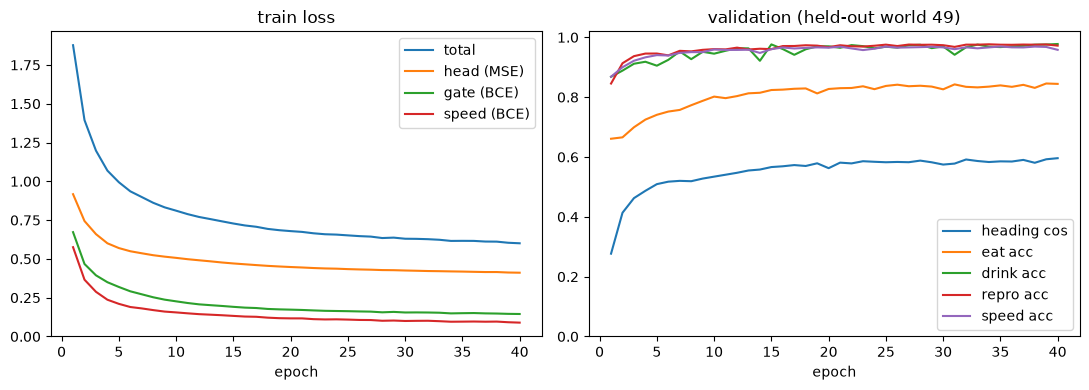

{'heading_cos': 0.596, 'eat_acc': 0.844, 'drink_acc': 0.978, 'repro_acc': 0.972, 'speed_acc': 0.958}


In [9]:
ep = [h['epoch'] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [h['tr_loss'] for h in history], label='total')
ax[0].plot(ep, [h['tr_head'] for h in history], label='head (MSE)')
ax[0].plot(ep, [h['tr_gate'] for h in history], label='gate (BCE)')
ax[0].plot(ep, [h['tr_speed'] for h in history], label='speed (BCE)')
ax[0].set_title('train loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(ep, [h['heading_cos'] for h in history], label='heading cos')
ax[1].plot(ep, [h['eat_acc'] for h in history], label='eat acc')
ax[1].plot(ep, [h['drink_acc'] for h in history], label='drink acc')
ax[1].plot(ep, [h['repro_acc'] for h in history], label='repro acc')
ax[1].plot(ep, [h['speed_acc'] for h in history], label='speed acc')
ax[1].set_title(f'validation (held-out world {VAL_WORLD})')
ax[1].set_xlabel('epoch'); ax[1].set_ylim(0, 1.02); ax[1].legend()
plt.tight_layout(); plt.show()

final = history[-1]
print({k: round(final[k], 3) for k in ('heading_cos','eat_acc','drink_acc','repro_acc','speed_acc')})

## Save the model

In [10]:
path = IL.save_model(SID, model, meta={'epochs': len(history),
                                          'val_world': VAL_WORLD,
                                          'final': history[-1]})
print("saved ->", path)

saved -> C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\sheep.pt
